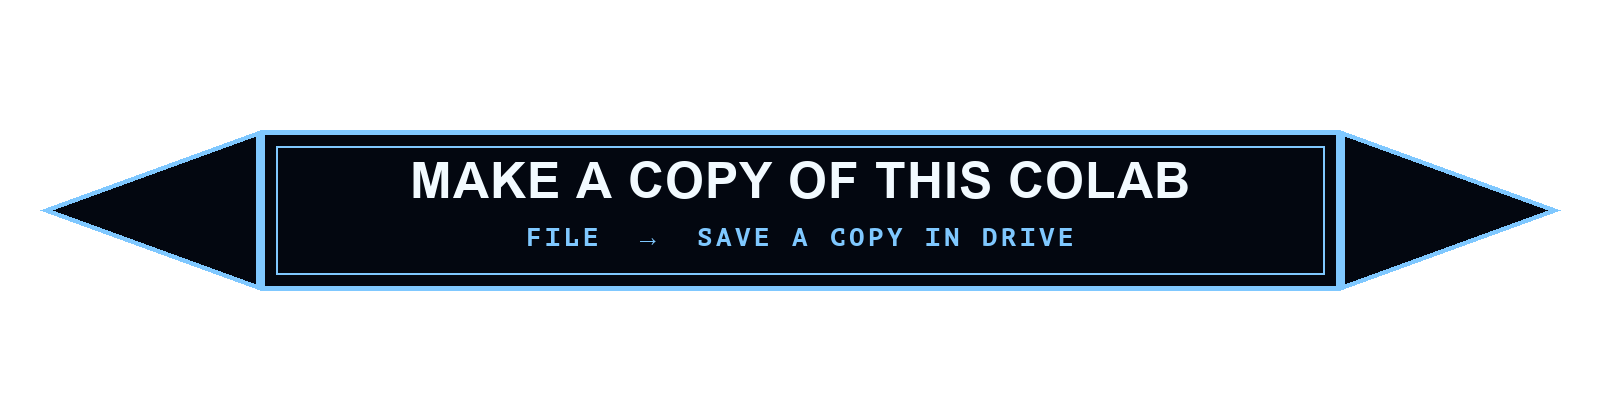

# Conference follow-up agent

Built on the Deep Agents 101 template: a useful agent for tonight. It turns rough notes about people you met at Interrupt into short, personalized LinkedIn follow-up messages, and it pauses for your approval before any message is finalized.

For topics not covered today, see the self-paced [LangChain Academy Deep Agents course.](https://academy.langchain.com/courses/foundation-introduction-to-deepagents)

In [ ]:
# Wraps text to make it easier to read

from IPython.display import HTML, display

def set_css():
    display(HTML('''
    <style>
      pre { white-space: pre-wrap; word-break: break-word; }
    </style>
    '''))

get_ipython().events.register('pre_run_cell', set_css)

## Setup: connect a model

**What you'll do:** install the SDKs and provide a model key.

In [ ]:
%pip install -q deepagents langgraph langchain-nvidia-ai-endpoints langchain-openai langchain-anthropic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.6/335.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.0/805.0 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/26

In [ ]:
from google.colab import userdata

ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")

# To use an OpenAI key (or another model) instead, just switch it:
# OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="anthropic:claude-opus-5",
    api_key=ANTHROPIC_API_KEY,
)

# To use a different provider instead, replace the block above, for example:
# model = init_chat_model("openai:gpt-6", api_key=OPENAI_API_KEY)

## 1: Build the follow-up agent

**The idea:** after the conference you will have met a handful of people. This agent turns your rough notes into short, personalized LinkedIn follow-ups. It never finalizes a message without your approval (see section 5).

**Anatomy of a tool**: `@tool` turns a plain function into something the model can call:
- the **docstring** becomes the tool's description (how the model decides when to use it)
- the **type hints** become its input schema (what arguments it expects)
- the **return value** becomes what the model sees back

In [ ]:
from deepagents import create_deep_agent
from langchain.tools import tool
import json
import os
from datetime import date

CONTACTS_FILE = "contacts.json"
FOLLOW_UPS_DIR = "follow_ups"

def _load_contacts():
    if os.path.exists(CONTACTS_FILE):
        with open(CONTACTS_FILE) as f:
            return json.load(f)
    return []

def _save_contacts(contacts):
    with open(CONTACTS_FILE, "w") as f:
        json.dump(contacts, f, indent=2)

@tool
def save_contact(name: str, company: str, role: str, notes: str) -> str:
    """Save a person you met: name, company, role, and what you talked about."""
    contacts = _load_contacts()
    contacts.append({
        "name": name,
        "company": company,
        "role": role,
        "notes": notes,
        "met_on": str(date.today()),
    })
    _save_contacts(contacts)
    return f"Saved {name} ({role} at {company})."

@tool
def list_contacts() -> str:
    """List everyone saved so far, with their notes."""
    contacts = _load_contacts()
    if not contacts:
        return "No contacts saved yet."
    return "\n".join(
        f"- {c['name']} ({c['role']}, {c['company']}): {c['notes']}"
        for c in contacts
    )

@tool
def draft_follow_up(name: str) -> str:
    """Pull up a saved contact's notes so you can write their follow-up message."""
    contacts = _load_contacts()
    matches = [c for c in contacts if name.lower() in c["name"].lower()]
    if not matches:
        return f"No contact found matching '{name}'. Call list_contacts to see who is saved."
    c = matches[0]
    return f"{c['name']} ({c['role']}, {c['company']}). You talked about: {c['notes']}"

@tool
def send_follow_up(name: str, message: str) -> str:
    """Finalize a LinkedIn follow-up message for a contact. Writes it to follow_ups/<name>.txt for you to copy and send."""
    os.makedirs(FOLLOW_UPS_DIR, exist_ok=True)
    path = os.path.join(FOLLOW_UPS_DIR, f"{name.replace(' ', '_').lower()}.txt")
    with open(path, "w") as f:
        f.write(message)
    return f"Follow-up for {name} saved to {path}. Copy it into LinkedIn whenever you are ready."

system_prompt = """You are Sai's conference follow-up assistant. Your job is to turn rough notes about people he met into short, warm, personalized LinkedIn follow-up messages.

Rules for every message you write:
- Under 4 sentences.
- Include one specific reference to the actual conversation, never generic "great meeting you" fluff.
- Plain punctuation only. Never use em dashes.
- Never mention compensation.
- If the notes are too thin to personalize, ask Sai for one more detail instead of inventing one.

Workflow: use save_contact to store people, draft_follow_up to pull up notes before writing, and send_follow_up to finalize. Never finalize a message without going through send_follow_up."""

TOOLS = [save_contact, list_contacts, draft_follow_up, send_follow_up]

agent = create_deep_agent(
    model=model,
    system_prompt=system_prompt,
    tools=TOOLS,
)

message = "Hello"

result = agent.invoke({"messages": [{"role": "user", "content": message}]})

for m in result['messages']:
    m.pretty_print()

## 2: Save who you met

Tell the agent about people in plain language. It figures out which tool to call and what arguments to pass.

In [ ]:
message = (
    "Save two people I met today. First: Anika Rao, inference engineer at Baseten, "
    "we talked about cold starts on 70B models and warm pools versus weight-loading tricks. "
    "Second: David Odomirok, Executive Director at JPMorgan, we talked about their "
    "Jarvis agent building assembly line."
)

result = agent.invoke({"messages": [{"role": "user", "content": message}]})

for m in result['messages']:
    m.pretty_print()

## 3: Draft a follow-up (without finalizing anything)

The agent pulls up the contact's notes and writes a draft. Nothing is saved yet, finalizing happens in section 5 behind a human approval checkpoint.

In [ ]:
message = "Draft a follow-up message for Anika, but do not finalize or send anything yet."

result = agent.invoke({"messages": [{"role": "user", "content": message}]})

for m in result['messages']:
    m.pretty_print()

## 4: Short-term memory, so it remembers across turns

Short-term memory is managed using a **checkpointer**. The `thread_id` tracks the conversation: keep it the same and the agent remembers, change it and you start fresh. This is also what makes the human-in-the-loop pause in section 5 resumable.

In [ ]:
# Import the checkpointer

from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [ ]:
# The following thread_id is what tracks the conversation over turns, change the thread_id to change the conversation
config = {"configurable": {"thread_id": "followups"}}

In [ ]:
# Define agent from above with the checkpointer
agent = create_deep_agent(
    model=model,
    system_prompt=system_prompt,
    tools=TOOLS,
    checkpointer=checkpointer,
)

In [ ]:
# Ask about the contacts saved in section 2, the agent remembers them in this thread
message = "Who have I saved so far, and what did I talk about with each of them?"

result = agent.invoke({"messages": [{"role": "user", "content": message}]},
                      config=config)

for m in result['messages']:
    m.pretty_print()

# Follow-up in the same thread
message = "Now draft a follow-up for David too."

result = agent.invoke({"messages": [{"role": "user", "content": message}]},
                      config=config)

for m in result['messages']:
    m.pretty_print()

## 5: Human-in-the-loop, approve every message before it is finalized

**What this covers:** `interrupt_on` pauses the agent before `send_follow_up` runs, so you see the exact message text and can approve, edit, or reject it. Nothing gets finalized without your say-so.

Every tool call passes through an `Interrupt?` check. If a call matches a rule in `interrupt_on`, the agent pauses and hands control to you instead of executing it. This pause only works because a `checkpointer` is attached: it saves the agent's state at the interrupt point so the run can resume later. Resuming looks like calling `agent.invoke` again with `Command(resume={"decisions": [{"type": "approve"}]})`.

In [ ]:
from langgraph.types import Command

interrupt_config = {"send_follow_up": True}

agent = create_deep_agent(
    model=model,
    system_prompt=system_prompt,
    tools=TOOLS,
    interrupt_on=interrupt_config,
    checkpointer=checkpointer,
)

config = {"configurable": {"thread_id": "followups"}}

result = agent.invoke(
    {"messages": [{"role": "user", "content":
        "Finalize and send the follow-up for Anika."
    }]},
    config=config,
)

if "__interrupt__" in result:
    request = result["__interrupt__"][0].value
    print("Paused for approval:")
    for action in request["action_requests"]:
        print(f"  {action['name']}({action['args']})")
else:
    print(result["messages"][-1].content)

The cell above should pause instead of finishing, because `send_follow_up` matched `interrupt_on`. Run the cell below to resume it with an approval decision.

In [ ]:
# Other decisions you could pass here instead of "approve":
#   {"type": "reject", "message": "..."}  # skip the tool call; `message` (optional) tells the agent why, so it doesn't just retry
#   {"type": "edit", "edited_action": {"name": "send_follow_up", "args": {"name": "Anika Rao", "message": "Your edited message here"}}}  # finalize, but with your own text
result = agent.invoke(Command(resume={"decisions": [{"type": "approve"}]}), config=config)
print(result["messages"][-1].content)

## Wrap-up

You built: a conference follow-up agent with a real job to do tonight.
- a system prompt that sets its role and its writing rules (short, specific, no em dashes, no comp talk)
- four custom tools: save_contact, list_contacts, draft_follow_up, send_follow_up
- short-term memory via checkpointer + thread_id, so it remembers your contacts across turns
- human-in-the-loop gating on send_follow_up, so every message gets your approval

Tonight: run section 2 for each person you met, then section 5 to approve each follow-up. Copy the saved files from follow_ups/ into LinkedIn.

Not covered today, but in the full LangChain Academy Deep Agents course: subagent delegation, backends (filesystem/store/composite), skills, memory across sessions, sandboxes, and deployment.